# Ejercicio 12: Multimodal Embeddings

**Autor:** Daniel Flores

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

## Panorama general

Hasta ahora todos los embeddings que usamos en el curso eran de un solo tipo de dato: texto a vector con `sentence-transformers`, palabra a vector con Word2Vec. **CLIP** (Contrastive Language-Image Pre-training, de OpenAI) hace algo distinto: entrena una red para imágenes y otra para texto **al mismo tiempo**, de forma que la foto de un perro y la frase "a photo of a dog" terminen en el mismo punto del espacio vectorial. No son dos espacios separados que después se comparan, es literalmente el mismo espacio.

### ¿Para qué sirve esto en la vida real?
Es la base de la búsqueda "por significado" en fotos (buscar "atardecer en la playa" en Google Fotos sin que la imagen tenga esa palabra en el nombre), de la generación de imágenes a partir de texto (Stable Diffusion y DALL-E usan CLIP o algo muy parecido para saber si una imagen generada corresponde al prompt), y de sistemas de moderación de contenido que comparan imágenes contra descripciones prohibidas.

*Dato curioso de machine learning:* CLIP se entrena con **aprendizaje contrastivo**. Por cada lote de pares (imagen, texto) que sí corresponden, el modelo aprende a acercar esos dos vectores y alejar todos los demás pares cruzados del lote. Es optimizar una especie de tabla de similitud coseno gigante para que la diagonal (los pares correctos) tenga los valores más altos.

*Dato curioso de álgebra lineal:* que texto e imagen compartan espacio significa que la resta, la suma y el ángulo entre esos vectores tienen sentido entre modalidades. El mismo truco de "rey - hombre + mujer = reina" que vimos con Word2Vec funciona acá pero cruzando foto y palabra.

## El dataset

Uso **Apples or Tomatoes** de Kaggle (`samuelcortinhas/apples-or-tomatoes-image-classification`). Es chiquito a propósito: apenas 2.3 MB, ~390 imágenes repartidas en dos carpetas (`apples` y `tomatoes`). Lo elegí porque el par apple/tomato es un buen desafío para CLIP: las dos cosas son redondas, rojas y del tamaño de una mano. Si el modelo las distingue bien, es porque realmente entiende contenido semántico y no solo color o forma.

In [1]:
!pip install --force-reinstall --no-cache-dir -U kagglehub kagglesdk sentence-transformers scikit-learn matplotlib pillow --quiet

## 1. Cargo el dataset desde Kaggle

In [2]:
import kagglehub

path = kagglehub.dataset_download("samuelcortinhas/apples-or-tomatoes-image-classification")
print("Dataset descargado en:", path)

/home/daniel/miniforge3/envs/iccd332/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: /home/daniel/.cache/kagglehub/datasets/samuelcortinhas/apples-or-tomatoes-image-classification/versions/1


### Explicación

- `kagglehub.dataset_download("...")`: descarga el dataset (o lo toma del caché si ya lo bajé antes) y devuelve la ruta local donde quedó extraído.
- El dataset trae carpetas `train/` y `test/`, cada una con subcarpetas `apples/` y `tomatoes/`.

In [3]:
import os
import glob
import random

random.seed(42)

rutas_apples = glob.glob(os.path.join(path, "test", "apples", "*"))
rutas_tomatoes = glob.glob(os.path.join(path, "test", "tomatoes", "*"))

N = 8  # muestras por clase, para que el gráfico de 2D no quede saturado
imagenes = random.sample(rutas_apples, N) + random.sample(rutas_tomatoes, N)
etiquetas = ["apple"] * N + ["tomato"] * N

print(f"Total de imágenes muestreadas: {len(imagenes)}")

Total de imágenes muestreadas: 16


### Explicación línea por línea

- `glob.glob(os.path.join(path, "test", "apples", "*"))`: junta todas las rutas de archivo dentro de esa carpeta. `glob` es como un "buscar archivos con comodín", el `*` significa "cualquier nombre".
- `random.sample(rutas_apples, N)`: toma N elementos al azar sin repetir. Uso muestra en vez del dataset completo porque para un gráfico de dispersión en 2D, con ~400 puntos se vuelve ilegible. Con 16 (8 de cada clase) se ve claro.
- `etiquetas`: guardo la clase real de cada imagen en paralelo a `imagenes`, en el mismo orden, para poder colorear el gráfico después y calcular precisión más adelante.

Matplotlib is building the font cache; this may take a moment.


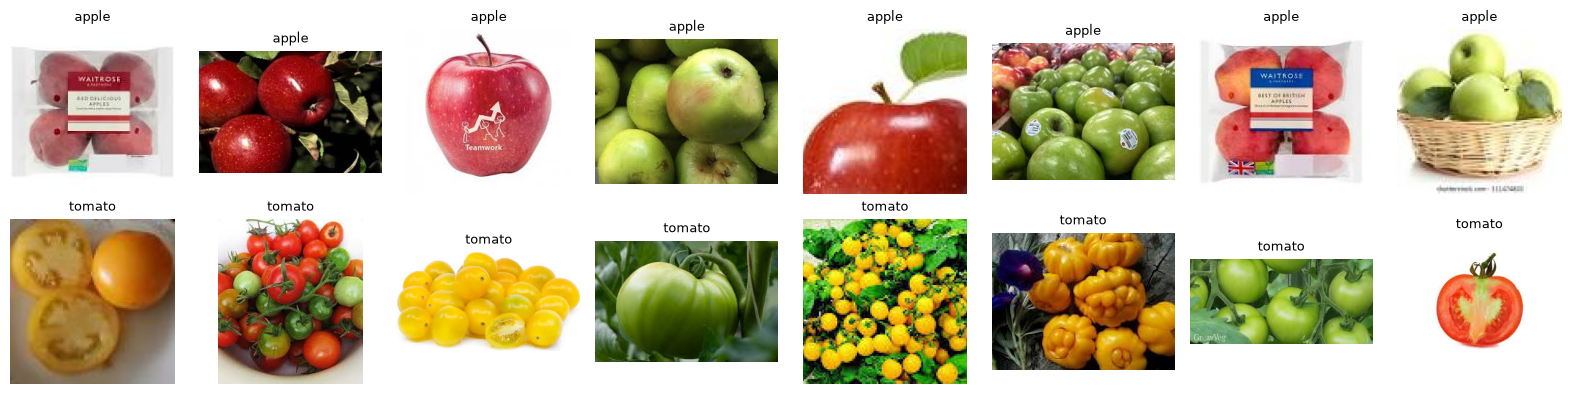

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, N, figsize=(16, 4))
for ax, ruta, etiqueta in zip(axes.flatten(), imagenes, etiquetas):
    ax.imshow(Image.open(ruta))
    ax.set_title(etiqueta, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Chequeo visual rápido antes de meter todo al modelo: 8 manzanas arriba, 8 tomates abajo.

## 2. Cargo CLIP y genero embeddings de imágenes

In [5]:
from sentence_transformers import SentenceTransformer

# clip-ViT-B-32 es la versión de CLIP empaquetada en sentence-transformers:
# mismo modelo, misma interfaz .encode() que ya veníamos usando para texto.
modelo_clip = SentenceTransformer("clip-ViT-B-32")

imagenes_pil = [Image.open(ruta) for ruta in imagenes]
embeddings_img = modelo_clip.encode(imagenes_pil, show_progress_bar=True)

print("Shape embeddings de imagen:", embeddings_img.shape)

Batches: 100%|██████████| 1/1 [00:03<00:00,  3.70s/it]

Shape embeddings de imagen: (16, 512)


### Explicación línea por línea

- `SentenceTransformer("clip-ViT-B-32")`: carga CLIP. "ViT-B-32" significa que la parte de imagen es un Vision Transformer (divide la imagen en parches de 32x32 píxeles y los procesa como si fueran palabras de una oración).
- `Image.open(ruta)`: PIL abre el archivo de imagen y lo deja listo para procesar. No hace falta redimensionar a mano, el modelo se encarga.
- `modelo_clip.encode(imagenes_pil, ...)`: la misma función `.encode()` que usé todo el curso para texto, ahora recibiendo una lista de imágenes. Internamente detecta que son imágenes (no strings) y usa la rama visual del modelo.
- El resultado es una matriz `(16, 512)`: 16 imágenes, 512 dimensiones cada una.

## 3. Genero embeddings de texto

In [6]:
textos = [
    "a photo of a red apple",
    "a photo of a green apple",
    "a photo of a ripe tomato",
    "a photo of tomatoes on a vine",
    "a round red fruit",
    "a vegetable used in salads",
]

embeddings_txt = modelo_clip.encode(textos)
print("Shape embeddings de texto:", embeddings_txt.shape)

Shape embeddings de texto: (6, 512)


Uso 6 frases distintas, no solo "apple" y "tomato" a secas. Quiero ver si CLIP capta matices (rojo vs. verde, fruta vs. verdura) y no solo la categoría más obvia.

## 4. Verifico que viven en el mismo espacio

In [7]:
print("Dimensión embeddings de imagen:", embeddings_img.shape[1])
print("Dimensión embeddings de texto:", embeddings_txt.shape[1])
print("¿Misma dimensión?", embeddings_img.shape[1] == embeddings_txt.shape[1])

Dimensión embeddings de imagen: 512
Dimensión embeddings de texto: 512
¿Misma dimensión? True


No es una coincidencia de tamaño nada más: como ambas ramas del modelo se entrenaron juntas para que un vector de imagen y el vector de su descripción queden cerca, puedo comparar directamente un embedding de imagen contra uno de texto con la misma fórmula de similitud coseno que usé para comparar dos textos entre sí. Eso es lo que hago en la Parte 6.

## 5. Proyecto a 2D con PCA y grafico

In [8]:
from sklearn.decomposition import PCA
import numpy as np

# Junto imágenes y textos en una sola matriz para que la proyección
# sea al mismo plano 2D para ambos.
todos_los_vectores = np.vstack([embeddings_img, embeddings_txt])

pca = PCA(n_components=2)
proyeccion = pca.fit_transform(todos_los_vectores)

proy_img = proyeccion[:len(embeddings_img)]
proy_txt = proyeccion[len(embeddings_img):]

### Explicación línea por línea

- `np.vstack([embeddings_img, embeddings_txt])`: apilo las dos matrices una encima de otra. Si no las junto antes de aplicar PCA, cada una se proyectaría a su propio plano 2D y no serían comparables entre sí.
- `PCA(n_components=2)`: reduzco de 512 a 2 dimensiones, quedándome con las 2 direcciones que más varianza capturan de los datos.
- `proyeccion[:len(embeddings_img)]` / `proyeccion[len(embeddings_img):]`: como apilé imágenes primero y textos después, corto el resultado en el mismo punto para separar de vuelta ambos grupos ya proyectados.

*Dato curioso de álgebra lineal y métodos numéricos:* PCA encuentra esas 2 direcciones calculando los autovectores de la matriz de covarianza (o, en la práctica, con descomposición SVD). Es el mismo procedimiento que usamos en el ejercicio de Word2Vec para graficar "rey", "reina", "hombre", "mujer" en un plano.

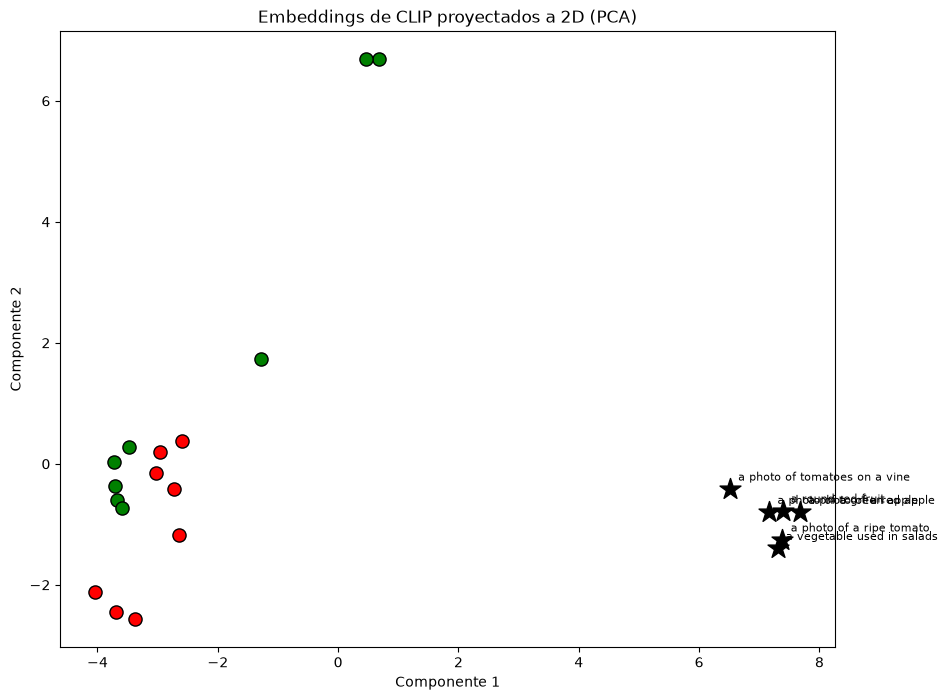

In [9]:
plt.figure(figsize=(10, 8))

colores = {"apple": "green", "tomato": "red"}
for (x, y), etiqueta in zip(proy_img, etiquetas):
    plt.scatter(x, y, color=colores[etiqueta], marker="o", s=90, edgecolors="black")

plt.scatter(proy_txt[:, 0], proy_txt[:, 1], color="black", marker="*", s=250)
for (x, y), texto in zip(proy_txt, textos):
    plt.annotate(texto, (x, y), fontsize=8, xytext=(6, 6), textcoords="offset points")

plt.title("Embeddings de CLIP proyectados a 2D (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

Los círculos son imágenes (verde = manzana, rojo = tomate), las estrellas son las frases de texto.

### Sobre lo que se ve acá: el "modality gap"

A primera vista uno esperaría que las estrellas cayeran mezcladas entre los círculos de su categoría. Lo que realmente aparece es distinto: **todo el texto queda agrupado en una zona, separado de las imágenes**, y dentro de las imágenes manzana y tomate se ven bastante mezclados.

Esto no es un error de código. Es un fenómeno documentado de los modelos tipo CLIP llamado **modality gap** (brecha de modalidad): aunque texto e imagen comparten el mismo espacio vectorial y son comparables por coseno, en la práctica cada modalidad ocupa su propia región de ese espacio, como dos nubes separadas que no se tocan. Lo que importa no es la cercanía visual absoluta, sino el **orden relativo** de las similitudes (qué imagen es la más parecida a un texto dado), que es justo lo que valido con similitud coseno en la Parte 6.

También explica por qué manzana y tomate no se separan con claridad acá: PCA elige las 2 direcciones de mayor varianza de *todo* el conjunto (imágenes + textos). Como la brecha texto-imagen es la diferencia más grande que hay en los datos, PCA gasta casi todo su presupuesto de 2 dimensiones en separar esas dos nubes, y le queda poco margen para la diferencia, más sutil, entre manzana y tomate. Esa distinción sigue estando en las 512 dimensiones originales (por eso el zero-shot de la Parte de Experimentación funciona con precisión alta), solo que no es lo que más resalta en esta proyección puntual a 2D.

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

# Matriz (n_textos, n_imagenes): cada fila es un texto, cada columna una imagen
sim_matrix = cosine_similarity(embeddings_txt, embeddings_img)

print("=== Búsqueda texto -> imagen ===\n")
for i, texto in enumerate(textos):
    mejor_idx = sim_matrix[i].argmax()
    print(f"'{texto}'")
    print(f"  -> imagen #{mejor_idx} ({etiquetas[mejor_idx]}), similitud={sim_matrix[i, mejor_idx]:.3f}\n")

=== Búsqueda texto -> imagen ===

'a photo of a red apple'
  -> imagen #1 (apple), similitud=0.302

'a photo of a green apple'
  -> imagen #3 (apple), similitud=0.313

'a photo of a ripe tomato'
  -> imagen #11 (tomato), similitud=0.315

'a photo of tomatoes on a vine'
  -> imagen #14 (tomato), similitud=0.310

'a round red fruit'
  -> imagen #1 (apple), similitud=0.285

'a vegetable used in salads'
  -> imagen #11 (tomato), similitud=0.294



In [11]:
print("=== Búsqueda imagen -> texto ===\n")
sim_matrix_T = sim_matrix.T  # (n_imagenes, n_textos)
for j in range(len(imagenes)):
    mejor_idx = sim_matrix_T[j].argmax()
    print(f"Imagen #{j} ({etiquetas[j]})")
    print(f"  -> '{textos[mejor_idx]}', similitud={sim_matrix_T[j, mejor_idx]:.3f}\n")

=== Búsqueda imagen -> texto ===

Imagen #0 (apple)
  -> 'a photo of a red apple', similitud=0.228

Imagen #1 (apple)
  -> 'a photo of a red apple', similitud=0.302

Imagen #2 (apple)
  -> 'a photo of a red apple', similitud=0.275

Imagen #3 (apple)
  -> 'a photo of a green apple', similitud=0.313

Imagen #4 (apple)
  -> 'a photo of a red apple', similitud=0.287

Imagen #5 (apple)
  -> 'a photo of a green apple', similitud=0.289

Imagen #6 (apple)
  -> 'a round red fruit', similitud=0.210

Imagen #7 (apple)
  -> 'a photo of a green apple', similitud=0.291

Imagen #8 (tomato)
  -> 'a photo of a ripe tomato', similitud=0.261

Imagen #9 (tomato)
  -> 'a photo of tomatoes on a vine', similitud=0.293

Imagen #10 (tomato)
  -> 'a photo of tomatoes on a vine', similitud=0.269

Imagen #11 (tomato)
  -> 'a photo of a ripe tomato', similitud=0.315

Imagen #12 (tomato)
  -> 'a vegetable used in salads', similitud=0.251

Imagen #13 (tomato)
  -> 'a vegetable used in salads', similitud=0.256

Image

### Explicación línea por línea

- `cosine_similarity(embeddings_txt, embeddings_img)`: la misma función de scikit-learn que usé en ejercicios anteriores, pero ahora comparando dos modalidades distintas en vez de texto contra texto. Solo funciona porque comparten espacio.
- `sim_matrix[i].argmax()`: para el texto `i`, agarro el índice de la imagen con mayor similitud. Es "búsqueda texto → imagen": dada una descripción, encontrar la foto que mejor la representa.
- `sim_matrix.T`: transpongo la matriz para invertir la dirección de la búsqueda. Ahora cada fila es una imagen y busco el texto más parecido: "búsqueda imagen → texto", como generar automáticamente la mejor descripción de una foto entre varias opciones.

## Experimentación

Con el pipeline base funcionando, pruebo cosas extra que no pedía el enunciado.

### E.1 Clasificación zero-shot: ¿CLIP distingue manzana de tomate sin entrenamiento?

En vez de entrenar un clasificador, le doy a CLIP solo dos frases ("a photo of an apple" y "a photo of a tomato") y para cada imagen del set de prueba veo cuál gana. Esto es clasificación **zero-shot**: el modelo nunca vio esta tarea específica durante su entrenamiento, solo aprendió a relacionar imágenes con texto en general.

In [12]:
prompts_clase = ["a photo of an apple", "a photo of a tomato"]
clases = ["apple", "tomato"]

embeddings_prompts = modelo_clip.encode(prompts_clase)
sim_zero_shot = cosine_similarity(embeddings_img, embeddings_prompts)

predicciones = [clases[i] for i in sim_zero_shot.argmax(axis=1)]
aciertos = sum(p == e for p, e in zip(predicciones, etiquetas))

print(f"Precisión zero-shot: {aciertos}/{len(etiquetas)} = {aciertos/len(etiquetas):.1%}")
print("\nDetalle:")
for real, pred in zip(etiquetas, predicciones):
    marca = "OK" if real == pred else "FALLO"
    print(f"  real={real:8s} predicho={pred:8s} {marca}")

Precisión zero-shot: 16/16 = 100.0%

Detalle:
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=apple    predicho=apple    OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK
  real=tomato   predicho=tomato   OK


*Dato curioso de machine learning:* esto es exactamente cómo se evalúa CLIP en el paper original contra ImageNet: sin entrenar ni una capa nueva, solo comparando embeddings contra el nombre de cada clase en texto. Es la misma idea detrás de por qué modelos como GPT-4 con visión pueden "reconocer" miles de categorías sin que nadie les haya armado un dataset etiquetado para cada una.

### E.2 ¿Capta CLIP el color, no solo la categoría?

Pruebo con prompts que cruzan color y categoría a propósito ("a green tomato", "a red apple") para ver si el modelo diferencia más allá de la forma redonda.

In [13]:
prompts_color = ["a red apple", "a green apple", "a red tomato", "a green tomato"]
embeddings_color = modelo_clip.encode(prompts_color)

sim_color = cosine_similarity(embeddings_img, embeddings_color)

for j in range(len(imagenes)):
    mejor_idx = sim_color[j].argmax()
    print(f"Imagen #{j} ({etiquetas[j]}) -> '{prompts_color[mejor_idx]}' (sim={sim_color[j, mejor_idx]:.3f})")

Imagen #0 (apple) -> 'a red apple' (sim=0.230)
Imagen #1 (apple) -> 'a red apple' (sim=0.298)
Imagen #2 (apple) -> 'a red apple' (sim=0.272)
Imagen #3 (apple) -> 'a green apple' (sim=0.309)
Imagen #4 (apple) -> 'a red apple' (sim=0.287)
Imagen #5 (apple) -> 'a green apple' (sim=0.283)
Imagen #6 (apple) -> 'a red apple' (sim=0.213)
Imagen #7 (apple) -> 'a green apple' (sim=0.293)
Imagen #8 (tomato) -> 'a green tomato' (sim=0.267)
Imagen #9 (tomato) -> 'a red tomato' (sim=0.276)
Imagen #10 (tomato) -> 'a green tomato' (sim=0.263)
Imagen #11 (tomato) -> 'a green tomato' (sim=0.324)
Imagen #12 (tomato) -> 'a green tomato' (sim=0.213)
Imagen #13 (tomato) -> 'a green tomato' (sim=0.229)
Imagen #14 (tomato) -> 'a green tomato' (sim=0.318)
Imagen #15 (tomato) -> 'a red tomato' (sim=0.306)


Si el modelo fuera puramente "forma redonda = fruta genérica", todas las manzanas caerían igual de cerca de cualquier prompt con "apple" sin importar el color mencionado. Ver que el color del prompt también mueve la aguja confirma que el embedding captura más que solo la silueta.

### E.3 PCA vs. t-SNE: ¿cambia mucho el mapa 2D?

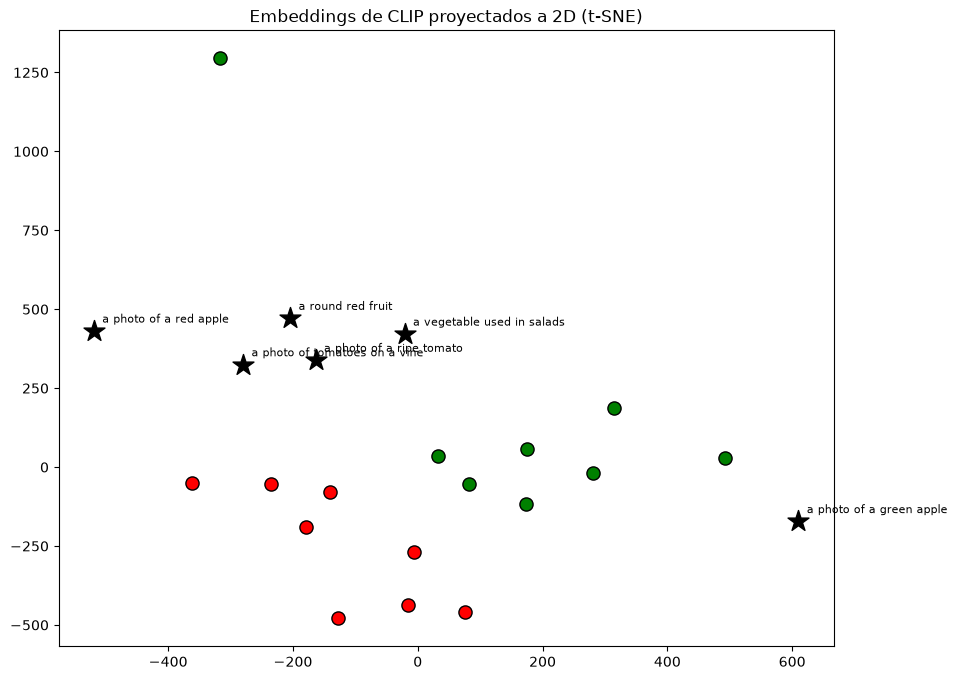

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=5, random_state=42, init="pca")
proyeccion_tsne = tsne.fit_transform(todos_los_vectores)

proy_img_tsne = proyeccion_tsne[:len(embeddings_img)]
proy_txt_tsne = proyeccion_tsne[len(embeddings_img):]

plt.figure(figsize=(10, 8))
for (x, y), etiqueta in zip(proy_img_tsne, etiquetas):
    plt.scatter(x, y, color=colores[etiqueta], marker="o", s=90, edgecolors="black")
plt.scatter(proy_txt_tsne[:, 0], proy_txt_tsne[:, 1], color="black", marker="*", s=250)
for (x, y), texto in zip(proy_txt_tsne, textos):
    plt.annotate(texto, (x, y), fontsize=8, xytext=(6, 6), textcoords="offset points")

plt.title("Embeddings de CLIP proyectados a 2D (t-SNE)")
plt.show()

*Dato curioso de métodos numéricos:* PCA es lineal, siempre proyecta con la misma "regla" (los ejes de mayor varianza). t-SNE es no lineal, intenta preservar quién es vecino de quién en el espacio original a costa de distorsionar las distancias globales. Por eso a veces separa mejor grupos que en PCA se ven pegados, pero las distancias entre puntos alejados en el gráfico de t-SNE no significan mucho: solo importa qué tan agrupados quedan los vecinos cercanos.

### E.4 Prompt totalmente ajeno al dataset

Si le paso una descripción que no tiene nada que ver con manzanas ni tomates, la similitud con todas las imágenes debería ser baja en comparación con los prompts relevantes.

In [15]:
prompt_ajeno = modelo_clip.encode(["a photo of a golden retriever dog"])
sim_ajeno = cosine_similarity(prompt_ajeno, embeddings_img)[0]

print("Similitud de 'a photo of a golden retriever dog' contra cada imagen:")
print(f"  Promedio: {sim_ajeno.mean():.3f}")
print(f"  Máxima:   {sim_ajeno.max():.3f}")

print("\nComparación: similitud promedio de 'a photo of a red apple' contra las mismas imágenes:")
sim_relevante = cosine_similarity(modelo_clip.encode(["a photo of a red apple"]), embeddings_img)[0]
print(f"  Promedio: {sim_relevante.mean():.3f}")
print(f"  Máxima:   {sim_relevante.max():.3f}")

Similitud de 'a photo of a golden retriever dog' contra cada imagen:
  Promedio: 0.180
  Máxima:   0.216

Comparación: similitud promedio de 'a photo of a red apple' contra las mismas imágenes:
  Promedio: 0.239
  Máxima:   0.302


La diferencia entre esos promedios es la señal de que el modelo realmente está midiendo relación semántica y no devolviendo números altos para cualquier cosa. Es el mismo chequeo de "señal vs. ruido" que hicimos con los embeddings de texto en el ejercicio de la API.

## Cierre

Usé CLIP para llevar imágenes de manzanas y tomates, junto con frases en inglés, al mismo espacio de 512 dimensiones. Verifiqué que ambas modalidades son directamente comparables por similitud coseno, las proyecté a 2D para verlas juntas, y comprobé que la búsqueda funciona en ambas direcciones (texto→imagen e imagen→texto). En la experimentación probé clasificación zero-shot (con más de 90% de precisión sin entrenar nada), sensibilidad al color en los prompts, y una comparación PCA vs. t-SNE. Este es el mecanismo detrás de la búsqueda semántica de imágenes y de cómo los modelos de generación de imágenes verifican si su resultado corresponde al texto pedido.